In [1]:
import numpy   as np
import pandas  as pd
import seaborn as sns

import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
import umap
import igraph as ig
import leidenalg

c:\Users\jm_ra\OneDrive\Documentos\investigacion\Network-Analysis-of-Quasars\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors     import kneighbors_graph
from sklearn.metrics       import silhouette_score

In [4]:
df = pd.read_csv("../data/processed/SDSS_DR16Q_phot_cleaned.csv")
print(df.describe())

               M_u          M_g          M_r          M_i          M_z  \
count  2824.000000  2824.000000  2824.000000  2824.000000  2824.000000   
mean    -23.182362   -23.423440   -23.778825   -23.901634   -24.076359   
std       1.031626     0.970065     0.947002     0.941231     0.961351   
min     -26.958090   -27.146076   -27.199040   -27.239652   -27.684719   
25%     -23.921718   -24.106451   -24.461496   -24.567493   -24.743927   
50%     -23.283706   -23.523989   -23.870375   -23.977608   -24.164478   
75%     -22.498244   -22.768555   -23.110437   -23.227284   -23.428469   
max     -17.730832   -16.781333   -19.506763   -18.276156   -18.854704   

             M_FUV        M_NUV         M_2j         M_2h         M_2k  \
count  2824.000000  2824.000000  2824.000000  2824.000000  2824.000000   
mean    -22.209506   -22.727516   -24.237591   -24.543130   -24.983764   
std       1.624406     1.455315     0.939656     0.842670     0.836177   
min     -26.006954   -26.484690   -28

In [5]:
df_features = pd.DataFrame(index=df.index)
# df_features = df["SDSS_NAME"]

# Colores Ópticos y UV (Pendiente del disco de acreción)
df_features['u_g'] = df['M_u'] - df['M_g']
df_features['g_r'] = df['M_g'] - df['M_r']
df_features['r_i'] = df['M_r'] - df['M_i']
df_features['i_z'] = df['M_i'] - df['M_z']
df_features['FUV_NUV'] = df['M_FUV'] - df['M_NUV']

# Colores Infrarrojos (Emisión térmica del polvo/toroide)
df_features['j_h'] = df['M_2j'] - df['M_2h']
df_features['h_k'] = df['M_2h'] - df['M_2k']
df_features['W1_W2'] = df['M_W1'] - df['M_W2']

# Cruces espectrales (Relación óptica-infrarroja)
df_features['opt_mir'] = df['M_i'] - df['M_W1']

In [6]:
print(df_features.describe())

               u_g          g_r          r_i          i_z      FUV_NUV  \
count  2824.000000  2824.000000  2824.000000  2824.000000  2824.000000   
mean      0.241078     0.355385     0.122809     0.174725     0.518011   
std       0.234280     0.178457     0.141153     0.130185     0.908031   
min      -4.870668    -1.162133    -3.743732    -0.469820    -2.326019   
25%       0.133301     0.263129     0.051054     0.109571     0.027186   
50%       0.201754     0.334887     0.112533     0.179806     0.266689   
75%       0.293187     0.417324     0.181806     0.249859     0.698555   
max       5.451188     5.479307     0.974532     1.710193     8.094675   

               j_h          h_k        W1_W2      opt_mir  
count  2824.000000  2824.000000  2824.000000  2824.000000  
mean      0.305539     0.440634     0.759429     1.655541  
std       0.287500     0.259329     0.169674     0.453336  
min      -1.415211    -0.849516     0.166172    -0.063083  
25%       0.144341     0.295867  

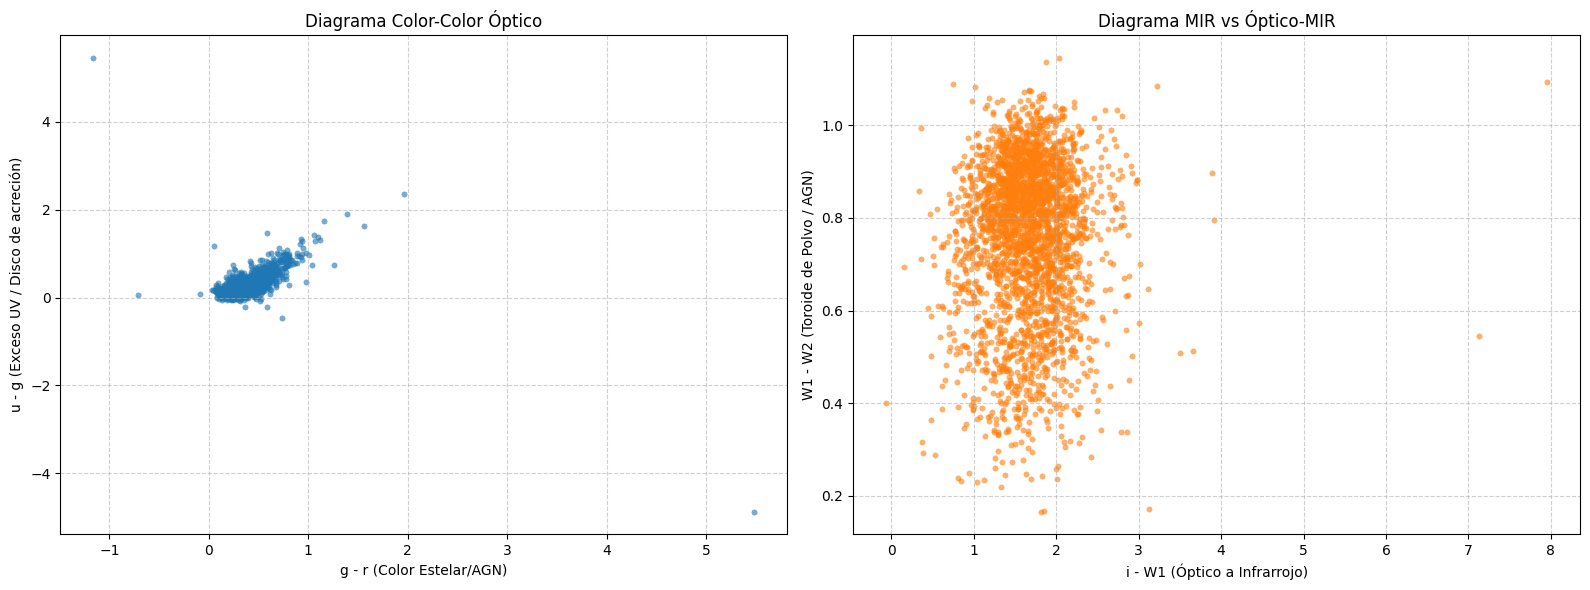

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_features, x='g_r', y='u_g', alpha=0.6, s=15, edgecolor=None, color='#1f77b4',ax=axes[0])
axes[0].set_title('Diagrama Color-Color Óptico')
axes[0].set_xlabel('g - r (Color Estelar/AGN)')
axes[0].set_ylabel('u - g (Exceso UV / Disco de acreción)')
axes[0].grid(True, linestyle='--', alpha=0.6)

sns.scatterplot(data=df_features, x='opt_mir', y='W1_W2', alpha=0.6, s=15, edgecolor=None, color='#ff7f0e',ax=axes[1])
axes[1].set_title('Diagrama MIR vs Óptico-MIR')
axes[1].set_xlabel('i - W1 (Óptico a Infrarrojo)')
axes[1].set_ylabel('W1 - W2 (Toroide de Polvo / AGN)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

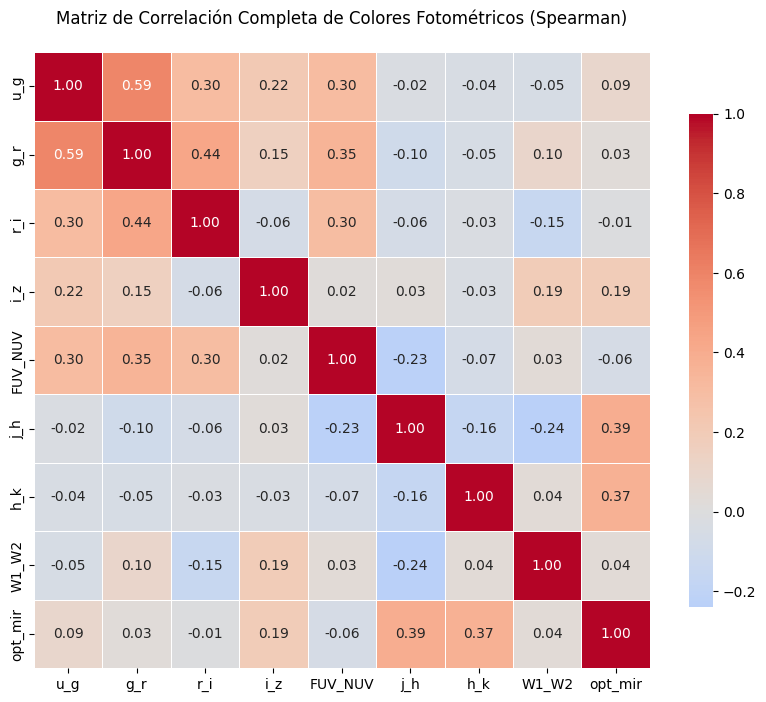

In [8]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_features.corr(method='spearman'), 
    cmap='coolwarm', 
    center=0,
    annot=True,     
    fmt=".2f",
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlación Completa de Colores Fotométricos (Spearman)', pad=20)
plt.show()


Antes de armar nuestra funcion de similitud o cualquier analisis topologico a nuestros datos es necesario escalarlos ya que estos no son invariantes a su escala o unidad de medida.

Si los datos no se normalizan, las características astronómicas que posean rangos de valores numéricos más amplios o unidades diferentes dominarán por completo el cálculo de distancias.

Al re-escalar los datos (utilizando métodos como Standard Scaling o MinMaxScaler), se logra una uniformidad en la escala que garantiza que todos los atributos contribuyan de manera equitativa a la estructura del grafo, evitando al mismo tiempo que los valores atípicos u outliers sesguen la agrupación

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

In [18]:
reducer = umap.UMAP(
    n_components=3, 
    n_neighbors=35,
    metric='manhattan',
)
X_umap = reducer.fit_transform(X_scaled)

In [19]:
k_vecinos = 35

# 1. Obtenemos el grafo de distancias (k-NN)
A_dist = kneighbors_graph(X_umap, n_neighbors=20, mode='distance', metric='manhattan')

# 2. Calculamos el ancho de banda (sigma) empírico
# Usamos la distancia media de todos los enlaces como factor de escala para suavizar
sigma = np.mean(A_dist.data)

# 3. Aplicamos el Heat Kernel (Kernel Gaussiano) a las distancias que NO son cero
A_dist.data = np.exp(- (A_dist.data**2) / (sigma**2))

# 4. Construimos el grafo de igraph
sources, targets = A_dist.nonzero()
weights = A_dist.data
grafo = ig.Graph(edges=list(zip(sources, targets)), directed=False)
grafo.es['weight'] = weights

In [42]:
partition = leidenalg.find_partition(
    grafo, 
    leidenalg.RBConfigurationVertexPartition, 
    weights=weights,
    resolution_parameter=0.1  # Modifica este valor entre 0.1 y 1.0 para afinar
)

labels = partition.membership
df['community'] = labels

In [43]:
sil_score = silhouette_score(X_umap, labels, metric='manhattan')

print(f"Total de comunidades detectadas: {max(labels) + 1}")
print(f"Silhouette Score: {sil_score:.3f}")

Total de comunidades detectadas: 6
Silhouette Score: 0.361


In [44]:
df_plot = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_plot['community'] = labels

# Convertimos a string para que Plotly y Seaborn lo traten como categoría, no como un continuo
df_plot['community'] = df_plot['community'].astype(str)

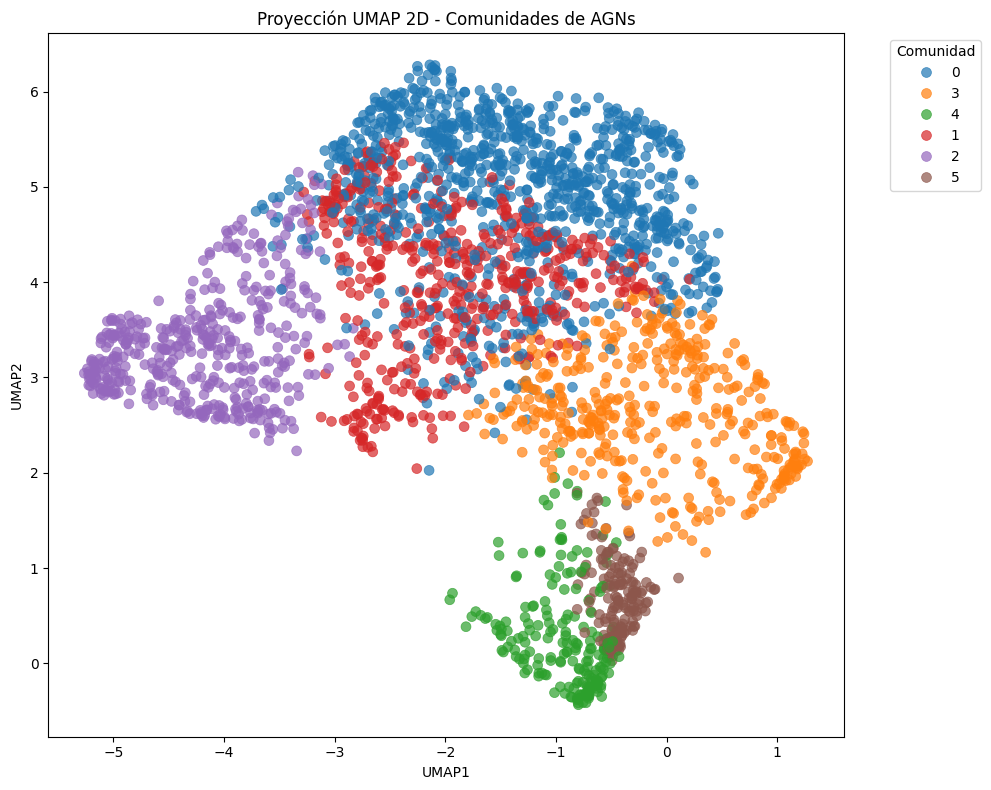

In [45]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='UMAP1', y='UMAP2', 
    hue='community', 
    palette='tab10', # Paleta categórica
    data=df_plot, 
    s=50, alpha=0.7, edgecolor=None
)
plt.title('Proyección UMAP 2D - Comunidades de AGNs')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Comunidad')
plt.tight_layout()
plt.savefig("../results/figures/umap_proyect2D.png", dpi=1200)

In [47]:
comunidades = [0, 1, 2, 3, 4, 5]

for i in comunidades:
    df_temp = df[df['community'] == i]
    
    filename = f'../data/communities/df_community_{i}.csv'
    df_temp.to_csv(filename, index=False)